# Function 2 - Week 3: exploration

Review the latest observations from `observations.csv` and continue the saved coverage shortlist.


In [1]:
# Imports & shared helpers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import sys

# Find Shared from any function/week folder inside notebooks.
shared_dir = next(
    (folder / "Shared"
     for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "Shared" / "plot_helpers.py").is_file()),
    None,
)
if shared_dir is None:
    raise FileNotFoundError(
        "Cannot find Shared/plot_helpers.py above the working directory. "
        "Run this notebook from within the notebooks folder."
    )
if str(shared_dir) not in sys.path:
    sys.path.insert(0, str(shared_dir))

from plot_helpers import (
    plot_sampling_gaps,
    plot_coverage_comparison,
    plot_output_distribution,
)
from output_helpers import summarise_output_observations


In [2]:
# Data and output paths for this week's notebook.
# Start the kernel with this notebook's folder as its working directory.
week_dir = Path.cwd().resolve()
full_data_path = week_dir / "observations.csv"

if not (week_dir / "exploration.ipynb").is_file() or not full_data_path.is_file():
    raise FileNotFoundError(
        "Run this notebook with its own folder as the working directory; "
        "exploration.ipynb and observations.csv must be together."
    )

figures = week_dir / "figures"
figures.mkdir(parents=True, exist_ok=True)



In [3]:
# Basic data load
print(f"Loading data from: {full_data_path}")
data = pd.read_csv(full_data_path)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\stage-2-bbo\notebooks\Function_2\Week_03\observations.csv


In [4]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'y'], dtype='str')


In [5]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
y                 0
dtype: int64


In [6]:
# Prepare observation labels for the exploration plots
plot_data = data.copy()
plot_data["rank"] = (
    plot_data["y"]
    .rank(ascending=False, method="min")
    .astype(int)
)

In [7]:
# Splitting our data into inputs X and outputs y
output_column = "y"
input_columns = ["x1", "x2"]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [8]:
# So now we have:

# data	       = Observations as loaded from the CSV
# X, y	       = Inputs and outputs selected from those observations
# plot_data	   = A separate copy enriched for the exploration plots

In [9]:
# Review the latest recorded submission against earlier observed outputs.
output_review = summarise_output_observations(
    data,
    input_columns=input_columns,
    output_column=output_column,
)
print(output_review["report"])


Latest recorded submission: round 2 (1 new output).
Compared with 11 earlier observations (12 outputs in total).
Earlier output range: [-0.0656236244373, 0.611205215761].

round-02: y = 0.0310950444551 (positive); rank 9/12 (1 = highest output).
Inputs: x1 = 0.228234, x2 = 0.066644
Within the earlier output range.


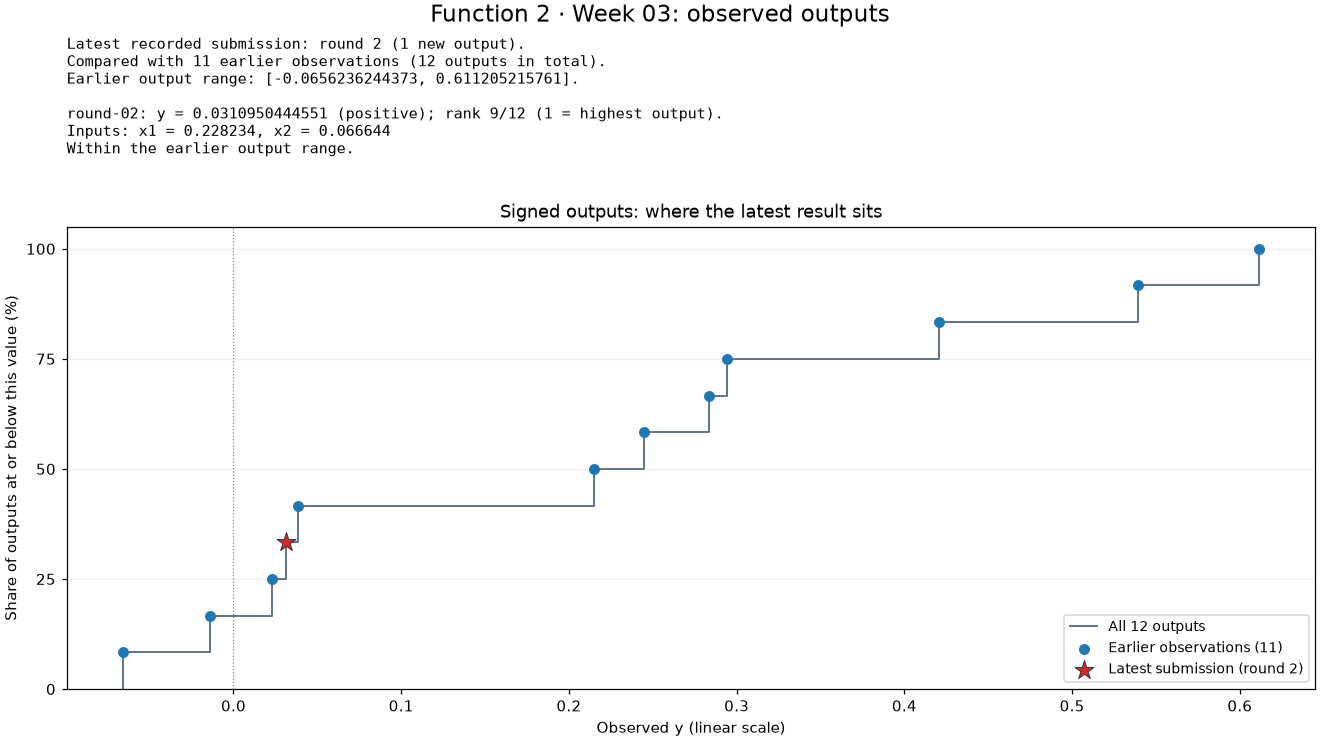

In [10]:
# Show every output, highlight the latest result and save a chart for the weekly write-up.
plot_output_distribution(
    output_review,
    title=f"{week_dir.parent.name.replace('_', ' ')} · {week_dir.name.replace('_', ' ')}: observed outputs",
    save_to=figures / "output-distribution.png",
)


## Observed ranks and sampling gaps

Circle numbers are observed output ranks (1 = highest). In the plan comparison, P1 and P2 are the remaining unevaluated samples in submission order.

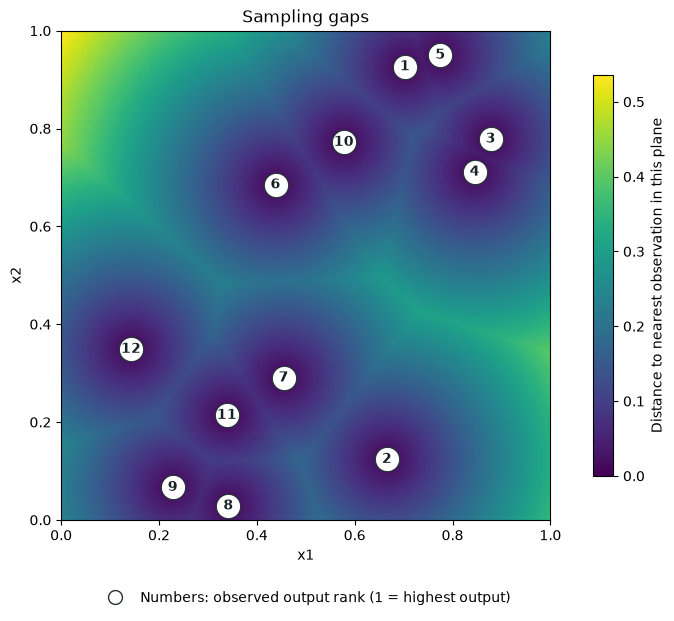

In [11]:
# Visualisation of input space coverage for query points we have so far 
plot_sampling_gaps(plot_data, save_to=figures / "sampling-gaps.png")

## Next query

The latest output, `0.031095044455081614`, is within the earlier range and did not improve the best observed value.
Continue with **`0.835565-0.232911`**, the next point on
[Week 2's shortlist](../Week_02/exploration.ipynb). The saved coordinates are reused without re-optimisation.


In [12]:
# Fixed Week 2 plan, preserved at full precision; no optimisation is run.
planned_queries = pd.DataFrame(
    [[0.22823414192856306, 0.06664413600559765], [0.8355651699511926, 0.23291097243365763], [0.17953980688500848, 0.8087368655610445]],
    columns=input_columns,
)

# The first planned point was evaluated in round 2.
coverage_queries = planned_queries.iloc[1:].copy()
coverage_queries


,x1,x2
1,0.835565,0.232911
2,0.179540,0.808737


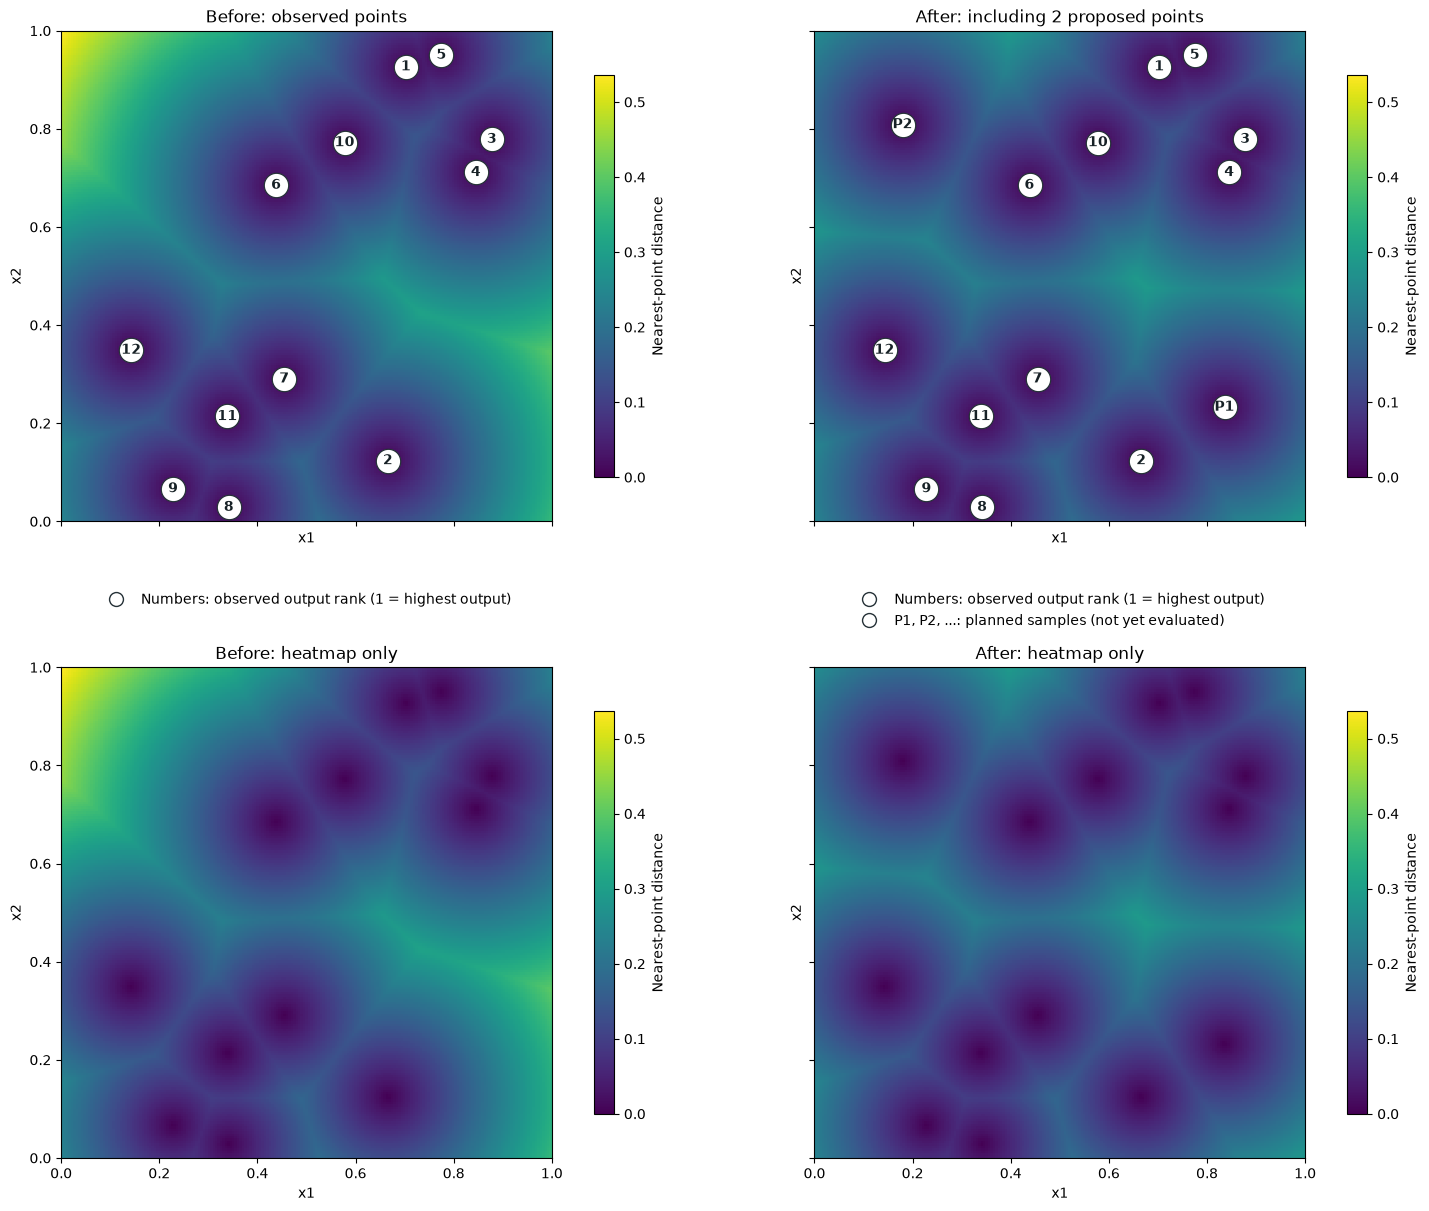

In [13]:
# Plot the remaining fixed plan against the updated observations; no search.
# None uses the before maximum; set vmax to keep a fixed scale across weeks.
plot_coverage_comparison(
    plot_data,
    coverage_queries,
    vmax=None,
    save_to=figures / "sampling-gaps-comparison.png",
)


In [14]:
# Restate the next two submissions in their saved order.
for week, point in enumerate(coverage_queries.to_numpy(), start=3):
    portal_input = "-".join(f"{value:.6f}" for value in point)
    print(f"Week {week}: {portal_input}")


Week 3: 0.835565-0.232911
Week 4: 0.179540-0.808737
